# LTGuardian AML™ - Synthetic Data Generation

This notebook generates synthetic transaction data for AML (Anti-Money Laundering) behavioral modeling.

## Objectives:
1. Create realistic transaction patterns for **normal players** (3 types)
2. Simulate **suspicious players** (6 AML risk patterns)
3. Generate structured datasets for behavioral fingerprinting and anomaly detection

## Dataset Schema:
- **Transaction fields**: player_id, session_id, timestamp, bet_amount, balance, deposits, withdrawals
- **Behavioral fields**: time_since_last_action, device, IP, location, game_result
- **Game context**: bet_direction (player/banker/tie for Baccarat-style games)

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import random

In [2]:
def random_ip():
    return f"10.{random.randint(0,255)}.{random.randint(0,255)}.{random.randint(0,255)}"

def random_device():
    return random.choice(["iPhone", "Android", "PC", "ETG"])

def random_location():
    return random.choice(["Macau", "US", "EU", "VPN"])

def random_game_result():
    return random.choice(["Win", "Lose"])

def jitter_seconds(base, jitter=3):
    return base + random.uniform(-jitter, jitter)


## Helper Functions
Utility functions for generating random contextual data (IP addresses, devices, locations, game results)

In [3]:
def generate_action(
    player_id,
    session_id,
    timestamp,
    balance,
    bet_amount,
    interval_sec,
    bet_direction="player"
):
    balance_after = balance - bet_amount
    return {
        "player_id": player_id,
        "session_id": session_id,
        "timestamp": timestamp,
        "bet_amount": bet_amount,
        "balance_before": balance,
        "balance_after": balance_after,
        "deposit_amount": None,
        "withdraw_amount": None,
        "game_result": random_game_result(),
        "device": random_device(),
        "ip_address": random_ip(),
        "location": random_location(),
        "time_since_last_action": interval_sec,
        "bet_direction": bet_direction
    }, balance_after


## Action Generators
Functions to generate different types of player actions (bets, deposits, withdrawals)

In [4]:
def generate_deposit(player_id, session_id, timestamp, balance, deposit_amount):
    """Generate a deposit action"""
    balance_after = balance + deposit_amount
    return {
        "player_id": player_id,
        "session_id": session_id,
        "timestamp": timestamp,
        "bet_amount": None,
        "balance_before": balance,
        "balance_after": balance_after,
        "deposit_amount": deposit_amount,
        "withdraw_amount": None,
        "game_result": None,
        "device": random_device(),
        "ip_address": random_ip(),
        "location": random_location(),
        "time_since_last_action": None,
        "bet_direction": None
    }, balance_after

def generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount):
    """Generate a withdrawal action"""
    balance_after = balance - withdraw_amount
    return {
        "player_id": player_id,
        "session_id": session_id,
        "timestamp": timestamp,
        "bet_amount": None,
        "balance_before": balance,
        "balance_after": balance_after,
        "deposit_amount": None,
        "withdraw_amount": withdraw_amount,
        "game_result": None,
        "device": random_device(),
        "ip_address": random_ip(),
        "location": random_location(),
        "time_since_last_action": None,
        "bet_direction": None
    }, balance_after

## Normal Player Simulators

Generate realistic baseline behavior for 3 types of normal players:
- **Type A**: Casual Low Bettor (small bets, slow rhythm, stable)
- **Type B**: Medium Stable Bettor (consistent range, long sessions)
- **Type C**: Hot/Cold Player (variance based on wins/losses, chase behavior)

In [5]:
def simulate_normal_player_A(player_id, num_sessions=5, start_date=None):
    """
    Normal Type A - Casual Low Bettor
    - Small bets (10-50)
    - Slow rhythm (5-12 seconds between bets)
    - No sudden spikes
    - Linear deposit/withdraw patterns
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    actions = []
    
    for sess_idx in range(num_sessions):
        session_id = f"{player_id}_S{sess_idx:03d}"
        session_start = start_date + timedelta(days=random.randint(0, 30), hours=random.randint(8, 22))
        
        # Initial deposit
        initial_deposit = random.randint(200, 500)
        balance = 0
        action, balance = generate_deposit(player_id, session_id, session_start, balance, initial_deposit)
        actions.append(action)
        
        # Play session: 15-30 bets
        timestamp = session_start + timedelta(seconds=random.randint(10, 60))
        num_bets = random.randint(15, 30)
        
        for bet_idx in range(num_bets):
            if balance < 10:
                break
                
            bet_amount = random.randint(10, 50)
            bet_amount = min(bet_amount, balance)  # Can't bet more than balance
            interval = jitter_seconds(random.uniform(5, 12))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            # Update balance based on game result
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)  # ~95% payout
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Withdraw remaining balance (if any)
        if balance > 50:
            timestamp += timedelta(seconds=random.randint(30, 120))
            withdraw_amount = balance * random.uniform(0.8, 1.0)  # Withdraw most of it
            action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
            actions.append(action)
    
    return actions

In [6]:
def simulate_normal_player_B(player_id, num_sessions=5, start_date=None):
    """
    Normal Type B - Medium Stable Bettor
    - Bets around consistent range (50-200)
    - Mild variance
    - Long stable sessions (20-40 mins, 40-80 bets)
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    actions = []
    base_bet = random.randint(75, 150)  # Player's preferred bet size
    
    for sess_idx in range(num_sessions):
        session_id = f"{player_id}_S{sess_idx:03d}"
        session_start = start_date + timedelta(days=random.randint(0, 30), hours=random.randint(8, 22))
        
        # Initial deposit
        initial_deposit = random.randint(2000, 5000)
        balance = 0
        action, balance = generate_deposit(player_id, session_id, session_start, balance, initial_deposit)
        actions.append(action)
        
        # Play session: 40-80 bets
        timestamp = session_start + timedelta(seconds=random.randint(10, 60))
        num_bets = random.randint(40, 80)
        
        for bet_idx in range(num_bets):
            if balance < 50:
                break
                
            # Bet around base_bet with mild variance
            bet_amount = int(np.random.normal(base_bet, base_bet * 0.15))
            bet_amount = np.clip(bet_amount, 50, 200)
            bet_amount = min(bet_amount, balance)
            
            interval = jitter_seconds(random.uniform(4, 8))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            # Update balance based on game result
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Withdraw remaining balance
        if balance > 100:
            timestamp += timedelta(seconds=random.randint(30, 180))
            withdraw_amount = balance * random.uniform(0.85, 1.0)
            action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
            actions.append(action)
    
    return actions

In [7]:
def simulate_normal_player_C(player_id, num_sessions=5, start_date=None):
    """
    Normal Type C - Hot/Cold Player
    - Behavioral swings based on results
    - Slightly higher variance
    - Occasional chase behavior (increases bet after losses)
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    actions = []
    
    for sess_idx in range(num_sessions):
        session_id = f"{player_id}_S{sess_idx:03d}"
        session_start = start_date + timedelta(days=random.randint(0, 30), hours=random.randint(8, 22))
        
        # Initial deposit
        initial_deposit = random.randint(1000, 3000)
        balance = 0
        action, balance = generate_deposit(player_id, session_id, session_start, balance, initial_deposit)
        actions.append(action)
        
        # Play session with hot/cold behavior
        timestamp = session_start + timedelta(seconds=random.randint(10, 60))
        num_bets = random.randint(30, 60)
        
        current_bet = random.randint(50, 150)
        consecutive_losses = 0
        
        for bet_idx in range(num_bets):
            if balance < 20:
                break
            
            bet_amount = min(current_bet, balance)
            interval = jitter_seconds(random.uniform(3, 10))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            # Update balance and adjust betting based on result
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
                consecutive_losses = 0
                # Slightly increase bet on win
                current_bet = int(current_bet * random.uniform(1.0, 1.2))
            else:
                consecutive_losses += 1
                # Chase losses: increase bet after 2-3 consecutive losses
                if consecutive_losses >= 2:
                    current_bet = int(current_bet * random.uniform(1.2, 1.5))
                else:
                    current_bet = int(current_bet * random.uniform(0.9, 1.1))
            
            # Keep bet in reasonable range
            current_bet = np.clip(current_bet, 20, 300)
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Withdraw remaining balance
        if balance > 100:
            timestamp += timedelta(seconds=random.randint(30, 180))
            withdraw_amount = balance * random.uniform(0.7, 1.0)
            action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
            actions.append(action)
    
    return actions

## Suspicious Player Simulators (AML Risk Patterns)

Generate 6 types of suspicious behavior patterns:
1. **Structuring**: Many small deposits to avoid attention
2. **Rapid In/Out**: Quick deposit → minimal play → immediate withdrawal
3. **High Volatility Spike**: Sudden abnormal bet size changes
4. **Multiple Accounts/Device Switching**: Coordinated behavior across accounts
5. **Bot-Like Behavior**: Perfectly consistent timing and patterns
6. **Crypto Abuse Pattern**: Intentional losses for laundering

In [8]:
def simulate_suspicious_structuring(player_id, num_sessions=3, start_date=None):
    """
    Suspicious Type 1 - Structuring Behavior
    AML RED FLAG: Many small deposits to avoid reporting thresholds
    - 15-25 small deposits (700-950 each)
    - Very low gameplay activity
    - Quick withdrawal afterward
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    actions = []
    
    for sess_idx in range(num_sessions):
        session_id = f"{player_id}_S{sess_idx:03d}"
        session_start = start_date + timedelta(days=random.randint(0, 10), hours=random.randint(8, 22))
        
        balance = 0
        timestamp = session_start
        
        # Multiple small deposits in quick succession
        num_deposits = random.randint(15, 25)
        for dep_idx in range(num_deposits):
            deposit_amount = random.randint(700, 950)  # Just under typical threshold
            action, balance = generate_deposit(player_id, session_id, timestamp, balance, deposit_amount)
            actions.append(action)
            timestamp += timedelta(seconds=random.randint(30, 180))  # 0.5-3 mins between deposits
        
        # Minimal gameplay (5-10 small bets only)
        timestamp += timedelta(seconds=random.randint(60, 300))
        num_bets = random.randint(5, 10)
        
        for bet_idx in range(num_bets):
            bet_amount = random.randint(10, 30)
            bet_amount = min(bet_amount, balance)
            interval = jitter_seconds(random.uniform(5, 15))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Quick withdrawal of nearly all funds
        timestamp += timedelta(seconds=random.randint(60, 300))
        withdraw_amount = balance * random.uniform(0.95, 0.99)
        action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
        actions.append(action)
    
    return actions

In [9]:
def simulate_suspicious_rapid_inout(player_id, num_sessions=4, start_date=None):
    """
    Suspicious Type 2 - Rapid In/Out Behavior
    AML RED FLAG: Money laundering through minimal activity
    - Deposits large amount (8000-12000)
    - Bets 5-10 very small bets
    - Withdraws 95-98% immediately
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    actions = []
    
    for sess_idx in range(num_sessions):
        session_id = f"{player_id}_S{sess_idx:03d}"
        session_start = start_date + timedelta(days=random.randint(0, 15), hours=random.randint(8, 22))
        
        # Large deposit
        initial_deposit = random.randint(8000, 12000)
        balance = 0
        action, balance = generate_deposit(player_id, session_id, session_start, balance, initial_deposit)
        actions.append(action)
        
        # Very minimal gameplay (5-10 bets, very small amounts)
        timestamp = session_start + timedelta(seconds=random.randint(120, 300))
        num_bets = random.randint(5, 10)
        
        for bet_idx in range(num_bets):
            bet_amount = random.randint(10, 50)
            bet_amount = min(bet_amount, balance)
            interval = jitter_seconds(random.uniform(8, 20))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Immediate large withdrawal (95-98% of deposit)
        timestamp += timedelta(seconds=random.randint(30, 120))
        withdraw_amount = balance * random.uniform(0.95, 0.98)
        action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
        actions.append(action)
    
    return actions

In [10]:
def simulate_suspicious_volatility_spike(player_id, num_sessions=3, start_date=None):
    """
    Suspicious Type 3 - High Volatility Spike
    AML RED FLAG: Abnormal behavior change
    - Normally bets 30-70
    - Suddenly bets 3000-6000 (2-3 times)
    - Returns to normal betting
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    actions = []
    
    for sess_idx in range(num_sessions):
        session_id = f"{player_id}_S{sess_idx:03d}"
        session_start = start_date + timedelta(days=random.randint(0, 20), hours=random.randint(8, 22))
        
        # Large deposit to enable spike behavior
        initial_deposit = random.randint(8000, 15000)
        balance = 0
        action, balance = generate_deposit(player_id, session_id, session_start, balance, initial_deposit)
        actions.append(action)
        
        timestamp = session_start + timedelta(seconds=random.randint(30, 120))
        
        # Phase 1: Normal betting (15-25 bets)
        num_normal_bets = random.randint(15, 25)
        for bet_idx in range(num_normal_bets):
            bet_amount = random.randint(30, 70)
            bet_amount = min(bet_amount, balance)
            interval = jitter_seconds(random.uniform(5, 10))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Phase 2: SPIKE - 2-3 massive bets
        num_spike_bets = random.randint(2, 3)
        for spike_idx in range(num_spike_bets):
            if balance < 1000:
                break
                
            spike_bet = random.randint(3000, 6000)
            spike_bet = min(spike_bet, balance)
            interval = jitter_seconds(random.uniform(10, 25))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, spike_bet, interval
            )
            
            if action["game_result"] == "Win":
                win_amount = spike_bet * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Phase 3: Return to normal betting (10-15 bets)
        num_normal_after = random.randint(10, 15)
        for bet_idx in range(num_normal_after):
            if balance < 30:
                break
                
            bet_amount = random.randint(30, 70)
            bet_amount = min(bet_amount, balance)
            interval = jitter_seconds(random.uniform(5, 10))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Withdraw
        if balance > 100:
            timestamp += timedelta(seconds=random.randint(30, 180))
            withdraw_amount = balance * random.uniform(0.85, 0.98)
            action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
            actions.append(action)
    
    return actions

In [11]:
def simulate_suspicious_coordinated_accounts(player_ids, start_date=None):
    """
    Suspicious Type 4 - Multiple Accounts / Device Switching
    AML RED FLAG: Coordinated behavior suggesting collusion or single entity
    - 2-3 players with identical betting rhythm
    - Same IP range
    - Shared device patterns
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    # Shared characteristics
    shared_ip_base = f"10.{random.randint(0,255)}.{random.randint(0,255)}"
    shared_device = random.choice(["iPhone", "Android", "PC"])
    shared_location = random.choice(["Macau", "VPN"])
    base_bet_pattern = random.randint(80, 150)
    base_interval = random.uniform(4, 7)
    
    all_actions = []
    
    for player_id in player_ids:
        actions = []
        session_id = f"{player_id}_S001"
        session_start = start_date + timedelta(days=random.randint(0, 5), hours=random.randint(10, 20))
        
        # Deposit
        initial_deposit = random.randint(2000, 4000)
        balance = 0
        action, balance = generate_deposit(player_id, session_id, session_start, balance, initial_deposit)
        # Override with shared characteristics
        action["ip_address"] = f"{shared_ip_base}.{random.randint(1, 10)}"
        action["device"] = shared_device
        action["location"] = shared_location
        actions.append(action)
        
        # Play with IDENTICAL rhythm
        timestamp = session_start + timedelta(seconds=random.randint(30, 90))
        num_bets = random.randint(30, 50)
        
        for bet_idx in range(num_bets):
            if balance < 50:
                break
            
            # Near-identical bet amounts
            bet_amount = int(np.random.normal(base_bet_pattern, base_bet_pattern * 0.08))
            bet_amount = np.clip(bet_amount, 50, 250)
            bet_amount = min(bet_amount, balance)
            
            # Near-identical timing
            interval = jitter_seconds(base_interval, jitter=0.5)  # Very low jitter
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            # Override with shared characteristics
            action["ip_address"] = f"{shared_ip_base}.{random.randint(1, 10)}"
            action["device"] = shared_device
            action["location"] = shared_location
            
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Withdraw
        if balance > 100:
            timestamp += timedelta(seconds=random.randint(30, 120))
            withdraw_amount = balance * random.uniform(0.85, 0.95)
            action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
            action["ip_address"] = f"{shared_ip_base}.{random.randint(1, 10)}"
            action["device"] = shared_device
            action["location"] = shared_location
            actions.append(action)
        
        all_actions.extend(actions)
    
    return all_actions

In [ ]:
def simulate_suspicious_bot_behavior(player_id, num_sessions=3, start_date=None):
    """
    Suspicious Type 5 - Bot-Like Behavior
    AML RED FLAG: Automated/scripted activity
    - Perfectly consistent timing (exact intervals, e.g., 2.0 sec)
    - Linear bet amounts (no variance)
    - No emotional variance or pattern changes
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    actions = []
    
    # Bot parameters (perfectly consistent)
    bot_bet_amount = random.choice([50, 75, 100, 150])  # Fixed bet size
    bot_interval = random.choice([1.5, 2.0, 2.5, 3.0])  # Exact timing
    
    for sess_idx in range(num_sessions):
        session_id = f"{player_id}_S{sess_idx:03d}"
        session_start = start_date + timedelta(days=random.randint(0, 15), hours=random.randint(0, 23))
        
        # Deposit
        initial_deposit = bot_bet_amount * random.randint(50, 100)
        balance = 0
        action, balance = generate_deposit(player_id, session_id, session_start, balance, initial_deposit)
        actions.append(action)
        
        # Bot play: perfectly consistent
        timestamp = session_start + timedelta(seconds=60)  # Exactly 60 seconds
        num_bets = random.randint(40, 80)
        
        for bet_idx in range(num_bets):
            if balance < bot_bet_amount:
                break
            
            # exact bet amount every time
            bet_amount = bot_bet_amount
            bet_amount = min(bet_amount, balance)
            
            # exact interval every time (no jitter)
            interval = bot_interval
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            
            if action["game_result"] == "Win":
                win_amount = bet_amount * random.uniform(0.9, 1.0)
                balance += win_amount
                action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Withdraw (if balance sufficient)
        if balance > bot_bet_amount:
            timestamp += timedelta(seconds=120)  # Exactly 120 seconds
            withdraw_amount = balance * random.uniform(0.90, 0.98)
            action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
            actions.append(action)
    
    return actions

In [13]:
def simulate_suspicious_crypto_laundering(player_id, num_sessions=3, start_date=None):
    """
    Suspicious Type 6 - Online Crypto Abuse Pattern
    AML RED FLAG: Intentional losses for laundering
    - Deposits via crypto (marked in location as "VPN")
    - Loses intentionally (high loss rate)
    - Cashes out via different method
    - Used for money laundering through "legitimate" gambling losses
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=30)
    
    actions = []
    
    for sess_idx in range(num_sessions):
        session_id = f"{player_id}_S{sess_idx:03d}"
        session_start = start_date + timedelta(days=random.randint(0, 20), hours=random.randint(8, 22))
        
        # Large crypto deposit
        initial_deposit = random.randint(5000, 15000)
        balance = 0
        action, balance = generate_deposit(player_id, session_id, session_start, balance, initial_deposit)
        action["location"] = "VPN"  # Indicator of crypto/anonymous deposit
        actions.append(action)
        
        # Play session with INTENTIONAL LOSSES
        timestamp = session_start + timedelta(seconds=random.randint(60, 180))
        num_bets = random.randint(30, 60)
        
        for bet_idx in range(num_bets):
            if balance < 100:
                break
            
            # Moderate to high bets
            bet_amount = random.randint(150, 500)
            bet_amount = min(bet_amount, balance)
            interval = jitter_seconds(random.uniform(4, 12))
            
            action, balance = generate_action(
                player_id, session_id, timestamp, balance, bet_amount, interval
            )
            action["location"] = "VPN"
            
            # BIASED toward losses (70% loss rate instead of ~50%)
            loss_probability = 0.70
            if random.random() > loss_probability:  # Only 30% wins
                if action["game_result"] == "Win":
                    win_amount = bet_amount * random.uniform(0.9, 1.0)
                    balance += win_amount
                    action["balance_after"] = balance
            
            actions.append(action)
            timestamp += timedelta(seconds=interval)
        
        # Withdraw remaining (smaller amount due to intentional losses)
        if balance > 100:
            timestamp += timedelta(seconds=random.randint(60, 300))
            withdraw_amount = balance * random.uniform(0.90, 0.98)
            action, balance = generate_withdrawal(player_id, session_id, timestamp, balance, withdraw_amount)
            action["location"] = "VPN"
            actions.append(action)
    
    return actions

## Dataset Generation & Export

Main functions to generate complete datasets combining normal and suspicious players

In [14]:
def generate_full_dataset(
    num_normal_A=50,
    num_normal_B=50,
    num_normal_C=50,
    num_suspicious_structuring=10,
    num_suspicious_rapid=10,
    num_suspicious_spike=10,
    num_suspicious_bot=8,
    num_suspicious_crypto=8,
    num_coordinated_groups=5,  # Groups of 2-3 accounts each
    start_date=None
):
    """
    Generate complete AML dataset with all player types
    
    Parameters:
    -----------
    num_normal_A/B/C : int
        Number of each type of normal player
    num_suspicious_* : int
        Number of each suspicious pattern type
    num_coordinated_groups : int
        Number of coordinated account groups (2-3 accounts per group)
    start_date : datetime
        Start date for simulations
    
    Returns:
    --------
    pd.DataFrame : Complete transaction dataset
    """
    if start_date is None:
        start_date = datetime.now() - timedelta(days=60)
    
    all_actions = []
    player_labels = {}  # Track which players are suspicious
    
    print("Generating normal players...")
    
    # Normal Player Type A
    for i in range(num_normal_A):
        player_id = f"NORM_A_{i:04d}"
        actions = simulate_normal_player_A(player_id, num_sessions=random.randint(3, 7), start_date=start_date)
        all_actions.extend(actions)
        player_labels[player_id] = "Normal_A"
    
    # Normal Player Type B
    for i in range(num_normal_B):
        player_id = f"NORM_B_{i:04d}"
        actions = simulate_normal_player_B(player_id, num_sessions=random.randint(3, 7), start_date=start_date)
        all_actions.extend(actions)
        player_labels[player_id] = "Normal_B"
    
    # Normal Player Type C
    for i in range(num_normal_C):
        player_id = f"NORM_C_{i:04d}"
        actions = simulate_normal_player_C(player_id, num_sessions=random.randint(3, 7), start_date=start_date)
        all_actions.extend(actions)
        player_labels[player_id] = "Normal_C"
    
    print("Generating suspicious players...")
    
    # Suspicious Type 1: Structuring
    for i in range(num_suspicious_structuring):
        player_id = f"SUSP_STRUCT_{i:04d}"
        actions = simulate_suspicious_structuring(player_id, num_sessions=random.randint(2, 4), start_date=start_date)
        all_actions.extend(actions)
        player_labels[player_id] = "Suspicious_Structuring"
    
    # Suspicious Type 2: Rapid In/Out
    for i in range(num_suspicious_rapid):
        player_id = f"SUSP_RAPID_{i:04d}"
        actions = simulate_suspicious_rapid_inout(player_id, num_sessions=random.randint(3, 5), start_date=start_date)
        all_actions.extend(actions)
        player_labels[player_id] = "Suspicious_RapidInOut"
    
    # Suspicious Type 3: Volatility Spike
    for i in range(num_suspicious_spike):
        player_id = f"SUSP_SPIKE_{i:04d}"
        actions = simulate_suspicious_volatility_spike(player_id, num_sessions=random.randint(2, 4), start_date=start_date)
        all_actions.extend(actions)
        player_labels[player_id] = "Suspicious_VolatilitySpike"
    
    # Suspicious Type 4: Coordinated Accounts
    for i in range(num_coordinated_groups):
        group_size = random.randint(2, 3)
        player_ids = [f"SUSP_COORD_{i:04d}_{j:02d}" for j in range(group_size)]
        actions = simulate_suspicious_coordinated_accounts(player_ids, start_date=start_date)
        all_actions.extend(actions)
        for pid in player_ids:
            player_labels[pid] = f"Suspicious_Coordinated_Group{i}"
    
    # Suspicious Type 5: Bot Behavior
    for i in range(num_suspicious_bot):
        player_id = f"SUSP_BOT_{i:04d}"
        actions = simulate_suspicious_bot_behavior(player_id, num_sessions=random.randint(3, 5), start_date=start_date)
        all_actions.extend(actions)
        player_labels[player_id] = "Suspicious_Bot"
    
    # Suspicious Type 6: Crypto Laundering
    for i in range(num_suspicious_crypto):
        player_id = f"SUSP_CRYPTO_{i:04d}"
        actions = simulate_suspicious_crypto_laundering(player_id, num_sessions=random.randint(2, 4), start_date=start_date)
        all_actions.extend(actions)
        player_labels[player_id] = "Suspicious_CryptoLaunder"
    
    print(f"Generated {len(all_actions)} total actions")
    
    # Convert to DataFrame
    df = pd.DataFrame(all_actions)
    
    # Add player label column
    df['player_label'] = df['player_id'].map(player_labels)
    
    # Add is_suspicious flag
    df['is_suspicious'] = df['player_label'].str.contains('Suspicious', na=False)
    
    # Sort by timestamp
    df = df.sort_values('timestamp').reset_index(drop=True)
    
    # Add noise: shuffle some timestamps slightly (realistic variance)
    df['timestamp'] = df['timestamp'].apply(
        lambda x: x + timedelta(seconds=random.uniform(-2, 2)) if pd.notnull(x) else x
    )
    
    print(f"Dataset shape: {df.shape}")
    print(f"Unique players: {df['player_id'].nunique()}")
    print(f"Suspicious players: {df[df['is_suspicious']]['player_id'].nunique()}")
    print(f"Normal players: {df[~df['is_suspicious']]['player_id'].nunique()}")
    
    return df

In [15]:
def save_dataset(df, filename='aml_synthetic_data.csv', output_dir='../data'):
    """
    Save dataset to CSV file
    
    Parameters:
    -----------
    df : pd.DataFrame
        Dataset to save
    filename : str
        Output filename
    output_dir : str
        Output directory path
    """
    import os
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    filepath = os.path.join(output_dir, filename)
    df.to_csv(filepath, index=False)
    
    print(f"Dataset saved to: {filepath}")
    print(f"File size: {os.path.getsize(filepath) / 1024:.2f} KB")
    
    return filepath

## Generate Dataset

Run the data generation and save to CSV file

In [16]:
# Generate the dataset
# Adjust parameters as needed for dataset size
df = generate_full_dataset(
    num_normal_A=50,
    num_normal_B=50,
    num_normal_C=50,
    num_suspicious_structuring=10,
    num_suspicious_rapid=10,
    num_suspicious_spike=10,
    num_suspicious_bot=8,
    num_suspicious_crypto=8,
    num_coordinated_groups=5
)

# Preview the dataset
df.head(20)

Generating normal players...
Generating suspicious players...
Generated 29526 total actions
Generating suspicious players...
Generated 29526 total actions
Dataset shape: (29526, 16)
Unique players: 209
Suspicious players: 59
Normal players: 150
Dataset shape: (29526, 16)
Unique players: 209
Suspicious players: 59
Normal players: 150


,player_id,session_id,timestamp,bet_amount,balance_before,balance_after,deposit_amount,withdraw_amount,game_result,device,ip_address,location,time_since_last_action,bet_direction,player_label,is_suspicious
0,NORM_A_0017,NORM_A_0017_S000,2025-11-09 01:06:32.427099,NaN,0.000000,390.000000,390.0,NaN,None,Android,10.186.145.40,EU,NaN,None,Normal_A,False
1,NORM_A_0017,NORM_A_0017_S000,2025-11-09 01:07:17.238626,23.0,390.000000,367.000000,NaN,NaN,Lose,Android,10.132.232.222,EU,5.818649,player,Normal_A,False
2,NORM_A_0017,NORM_A_0017_S000,2025-11-09 01:07:22.138274,47.0,367.000000,364.110304,NaN,NaN,Win,ETG,10.137.159.129,Macau,9.786067,player,Normal_A,False
3,NORM_A_0017,NORM_A_0017_S000,2025-11-09 01:07:30.412008,43.0,364.110304,321.110304,NaN,NaN,Lose,Android,10.86.59.60,Macau,6.257348,player,Normal_A,False
4,NORM_A_0017,NORM_A_0017_S000,2025-11-09 01:07:39.237516,14.0,321.110304,307.110304,NaN,NaN,Lose,ETG,10.245.240.82,EU,4.511317,player,Normal_A,False
5,NORM_A_0017,NORM_A_0017_S000,2025-11-09 01:07:42.679273,33.0,307.110304,305.880769,NaN,NaN,Win,PC,10.57.236.23,US,8.387279,player,Normal_A,False
6,NORM_A_0017,NORM_A_0017_S000,2025-11-09 01:07:51.047758,15.0,305.880769,304.914562,NaN,NaN,Win,Android,10.29.42.214,EU,3.608585,player,Normal_A,False
7,NORM_A_0017,NORM_A_0017_S000,2025-11-09 01:07:54.417293,34.0,304.914562,304.063397,NaN,NaN,Win,ETG,10.20.159.110,VPN,6.451069,player,Normal_A,False
8,NORM_A_0017,NORM_A_0017_S000,2025-11-09 01:07:59.089141,24.0,304.063397,280.063397,NaN,NaN,Lose,iPhone,10.199.252.129,EU,10.422086,player,Normal_A,False
9,NORM_A_0017,NORM_A_0017_S000,2025-11-09 01:08:10.767735,14.0,280.063397,266.063397,NaN,NaN,Lose,ETG,10.32.178.193,US,9.727012,player,Normal_A,False


In [17]:
# Dataset statistics
print("="*60)
print("DATASET STATISTICS")
print("="*60)
print(f"\nTotal transactions: {len(df)}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nUnique players: {df['player_id'].nunique()}")
print(f"  - Normal players: {df[~df['is_suspicious']]['player_id'].nunique()}")
print(f"  - Suspicious players: {df[df['is_suspicious']]['player_id'].nunique()}")

print("\n" + "="*60)
print("PLAYER TYPE DISTRIBUTION")
print("="*60)
print(df['player_label'].value_counts())

print("\n" + "="*60)
print("ACTION TYPE DISTRIBUTION")
print("="*60)
print(f"Bets: {df['bet_amount'].notna().sum()}")
print(f"Deposits: {df['deposit_amount'].notna().sum()}")
print(f"Withdrawals: {df['withdraw_amount'].notna().sum()}")

print("\n" + "="*60)
print("BET STATISTICS (excluding deposits/withdrawals)")
print("="*60)
bet_df = df[df['bet_amount'].notna()]
print(bet_df['bet_amount'].describe())

print("\n" + "="*60)
print("SAMPLE DATA")
print("="*60)
print(df[['player_id', 'timestamp', 'bet_amount', 'balance_before', 'balance_after', 
         'deposit_amount', 'withdraw_amount', 'player_label']].head(15))

DATASET STATISTICS

Total transactions: 29526
Date range: 2025-11-09 01:06:32.427099 to 2025-12-09 15:14:03.529531

Unique players: 209
  - Normal players: 150
  - Suspicious players: 59

PLAYER TYPE DISTRIBUTION
player_label
Normal_B                         12929
Normal_C                          5357
Normal_A                          5152
Suspicious_Bot                    2170
Suspicious_VolatilitySpike        1102
Suspicious_CryptoLaunder          1077
Suspicious_Structuring             889
Suspicious_RapidInOut              360
Suspicious_Coordinated_Group2      119
Suspicious_Coordinated_Group4      112
Suspicious_Coordinated_Group0      103
Suspicious_Coordinated_Group1       85
Suspicious_Coordinated_Group3       71
Name: count, dtype: int64

ACTION TYPE DISTRIBUTION
Bets: 27639
Deposits: 1533
Withdrawals: 354

BET STATISTICS (excluding deposits/withdrawals)
count    27639.000000
mean       127.571314
std        240.736550
min         10.000000
25%         59.000000
50%        1

In [ ]:
# Save the dataset
filepath = save_dataset(df, filename='aml_synthetic_data.csv', output_dir='../data')
print(f"\nDataset successfully saved to: {filepath}")

Dataset saved to: ../data/aml_synthetic_data.csv
File size: 4831.83 KB

✅ Dataset successfully saved to: ../data/aml_synthetic_data.csv


## Data Validation & Visualization

Quick visualization to verify data patterns

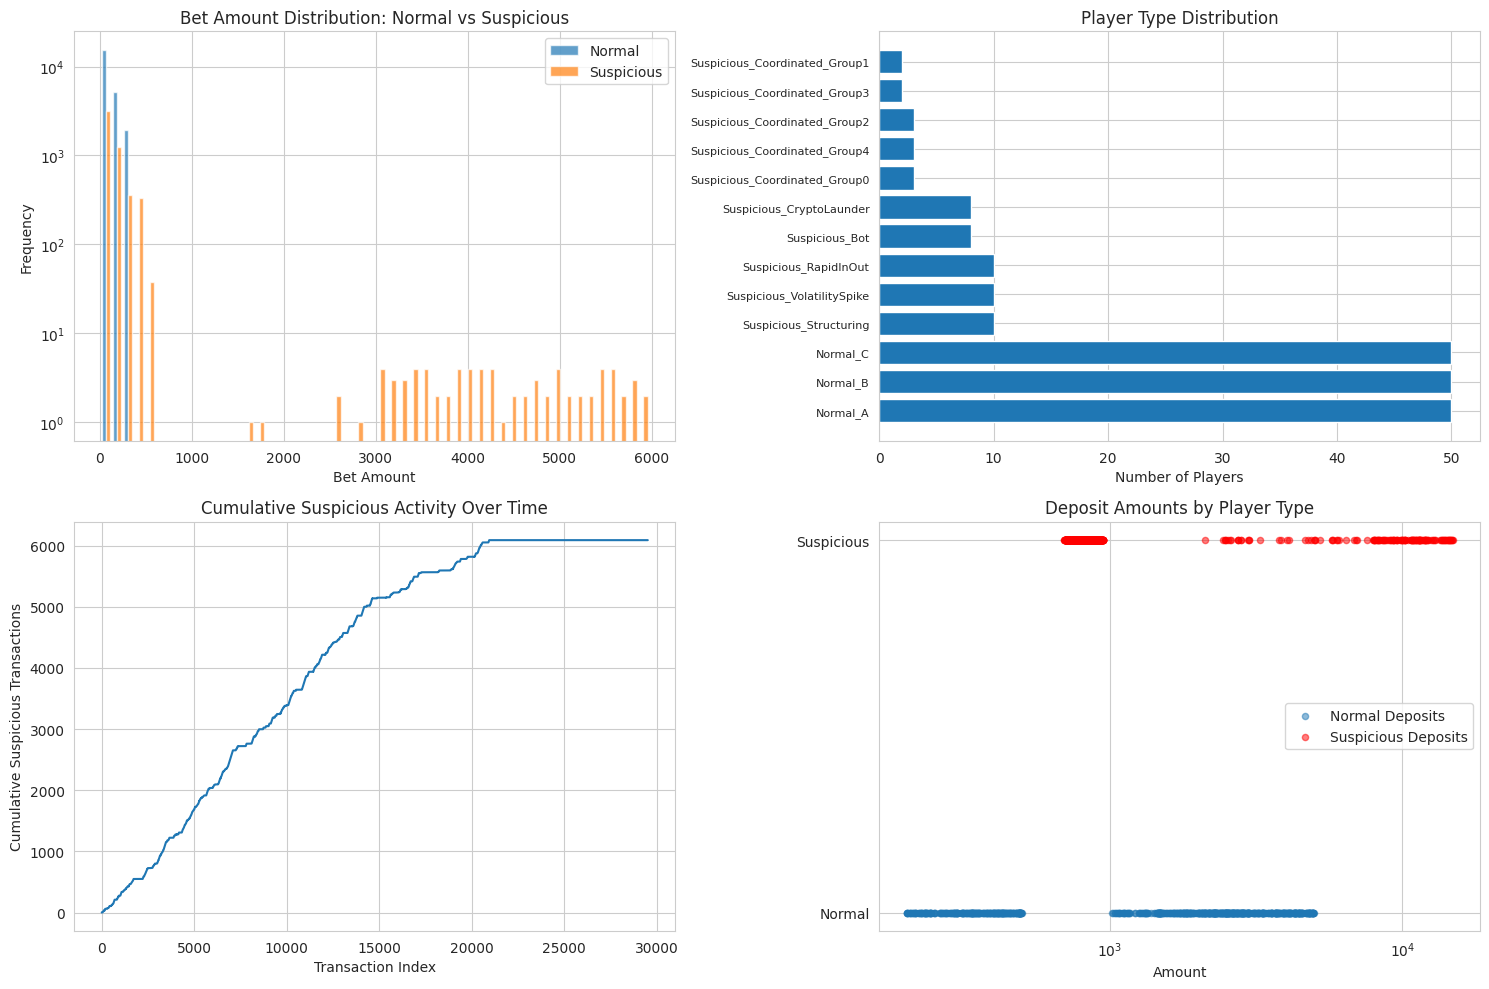

✅ Visualization saved to: ../data/data_generation_summary.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Bet amount distribution: Normal vs Suspicious
bet_df = df[df['bet_amount'].notna()].copy()
axes[0, 0].hist([bet_df[~bet_df['is_suspicious']]['bet_amount'], 
                 bet_df[bet_df['is_suspicious']]['bet_amount']], 
                bins=50, label=['Normal', 'Suspicious'], alpha=0.7)
axes[0, 0].set_xlabel('Bet Amount')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Bet Amount Distribution: Normal vs Suspicious')
axes[0, 0].legend()
axes[0, 0].set_yscale('log')

# 2. Player label distribution
player_label_counts = df.groupby('player_id')['player_label'].first().value_counts()
axes[0, 1].barh(range(len(player_label_counts)), player_label_counts.values)
axes[0, 1].set_yticks(range(len(player_label_counts)))
axes[0, 1].set_yticklabels(player_label_counts.index, fontsize=8)
axes[0, 1].set_xlabel('Number of Players')
axes[0, 1].set_title('Player Type Distribution')

# 3. Time series of suspicious activity
df_sorted = df.sort_values('timestamp')
df_sorted['cumulative_suspicious'] = df_sorted['is_suspicious'].cumsum()
axes[1, 0].plot(df_sorted.index, df_sorted['cumulative_suspicious'])
axes[1, 0].set_xlabel('Transaction Index')
axes[1, 0].set_ylabel('Cumulative Suspicious Transactions')
axes[1, 0].set_title('Cumulative Suspicious Activity Over Time')

# 4. Deposit vs Withdrawal amounts
deposit_data = df[df['deposit_amount'].notna()]
withdraw_data = df[df['withdraw_amount'].notna()]
axes[1, 1].scatter(deposit_data[~deposit_data['is_suspicious']]['deposit_amount'], 
                   [1]*len(deposit_data[~deposit_data['is_suspicious']]), 
                   alpha=0.5, label='Normal Deposits', s=20)
axes[1, 1].scatter(deposit_data[deposit_data['is_suspicious']]['deposit_amount'], 
                   [2]*len(deposit_data[deposit_data['is_suspicious']]), 
                   alpha=0.5, label='Suspicious Deposits', s=20, color='red')
axes[1, 1].set_xlabel('Amount')
axes[1, 1].set_yticks([1, 2])
axes[1, 1].set_yticklabels(['Normal', 'Suspicious'])
axes[1, 1].set_title('Deposit Amounts by Player Type')
axes[1, 1].set_xscale('log')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../data/data_generation_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved to: ../data/data_generation_summary.png")